In [1]:
import xarray as xr

# 1. Load your multi-year AVISO SLA data
ds = xr.open_dataset('/data/SO3/edavenport/tpose6/aviso_data/aviso_equatorial_pacific_1993to2012.nc') # 1993 through 2012 (daily)

In [2]:
ds

<xarray.Dataset> Size: 13GB
Dimensions:    (time: 7305, latitude: 160, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 58kB 1993-01-01 1993-01-02 ... 2012-12-31
  * latitude   (latitude) float32 640B -9.938 -9.812 -9.688 ... 9.812 9.938
  * longitude  (longitude) float32 3kB -179.9 -179.8 -179.7 ... -90.19 -90.06
Data variables:
    sla        (time, latitude, longitude) float64 7GB ...
    adt        (time, latitude, longitude) float64 7GB ...
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-12-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    copernicusmarine_version:        2.3.0

In [3]:
# 2. Calculate the monthly mean (this will be our forecast "guess")
monthly_mean = ds.sla.groupby("time.month").mean("time")

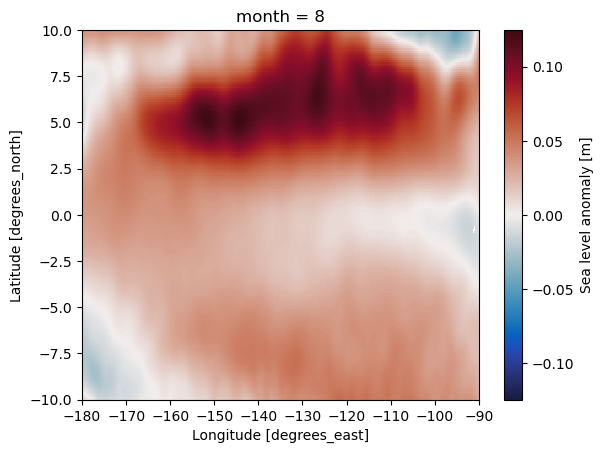

In [4]:
import cmocean.cm as cmo
monthly_mean.sel(month=8).plot(x='longitude',cmap=cmo.balance)

In [5]:
# 3. Calculate the standard deviation within each month
# This gives you one map per month showing how much SSH typically deviates
climatological_std = ds.sla.groupby("time.month").std("time")

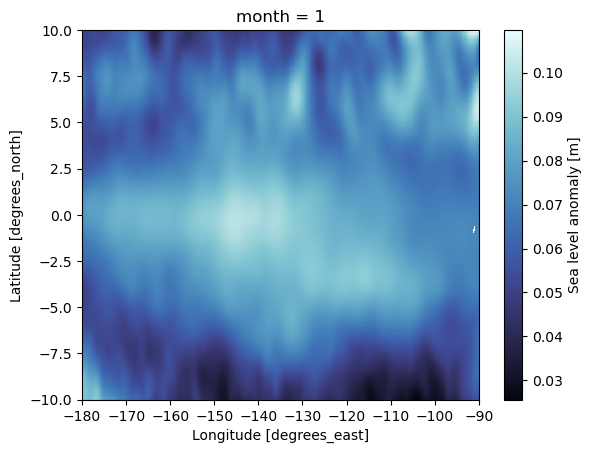

In [6]:
climatological_std.sel(month=1).plot(x='longitude',cmap=cmo.ice)

In [8]:
monthly_mean_adt = ds.adt.groupby("time.month").mean("time")
climatological_std_adt = ds.adt.groupby("time.month").std("time")

In [9]:
ds_stats = xr.Dataset({'adt_std': climatological_std_adt, 'adt_mean': monthly_mean_adt, 
                       'sla_std': climatological_std, 'sla_mean': monthly_mean})
ds_stats.to_netcdf('forecasts/aviso_data/aviso_climatology_1993to2012.nc')

In [ ]:
# # total non-seasonal variability across the whole record
# deseasonalized = ds.sla.groupby("time.month") - monthly_mean
# total_std = deseasonalized.std("time")